Practical no:6 implementation of the Time series analysis algorithm.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller


In [3]:
import requests

# URL for a sample stock data CSV. Replace with your actual file if different.
stock_data_url = "https://raw.githubusercontent.com/plotly/datasets/master/stockdata.csv"

# Download the file
response = requests.get(stock_data_url)
with open("/content/stock_data.csv", "wb") as f:
    f.write(response.content)

print("stock_data.csv downloaded to /content/")

stock_data.csv downloaded to /content/


In [4]:
df = pd.read_csv("/content/stock_data.csv",
                 parse_dates=True,
                 index_col="Date")
df.head()

,MSFT,IBM,SBUX,AAPL,GSPC
Date,,,,,
2007-01-03,23.950705,80.517962,16.149666,11.086612,1416.599976
2007-01-04,23.910599,81.378851,16.167992,11.332687,1418.339966
2007-01-05,23.774242,80.642129,16.099269,11.251984,1409.709961
2007-01-08,24.006852,81.867244,16.039710,11.307550,1412.839966
2007-01-09,24.030914,82.835742,15.970989,12.246870,1412.109985


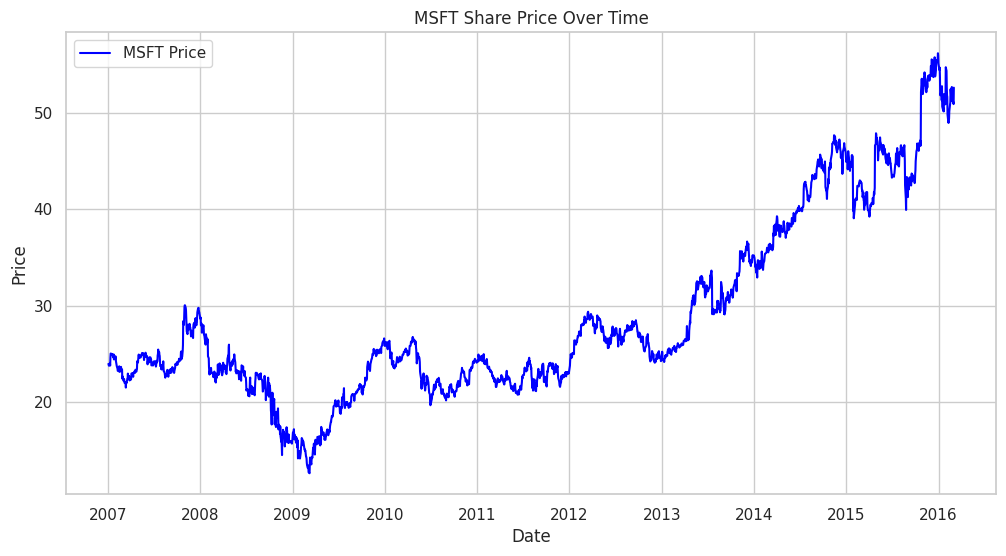

In [8]:
sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x=df.index, y='MSFT', label='MSFT Price', color='blue')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('MSFT Share Price Over Time')

plt.show()

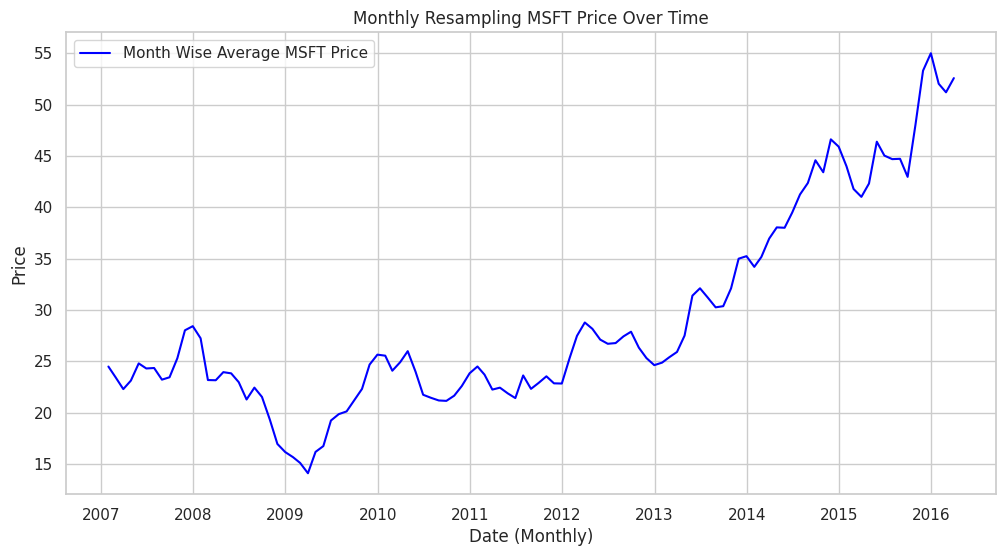

In [10]:
df_resampled = df.resample('ME').mean(numeric_only=True)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resampled, x=df_resampled.index, y='MSFT', label='Month Wise Average MSFT Price', color='blue')

plt.xlabel('Date (Monthly)')
plt.ylabel('Price')
plt.title('Monthly Resampling MSFT Price Over Time')

plt.show()

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

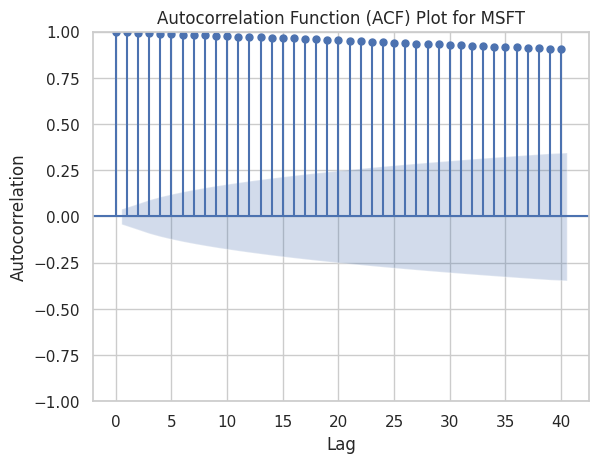

In [12]:
if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['MSFT'], lags=40) # Changed 'High' to 'MSFT'
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot for MSFT') # Updated title
plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['MSFT'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: 0.5077879482397025
p-value: 0.9851078923726959
Critical Values: {'1%': np.float64(-3.43320007524933), '5%': np.float64(-2.8627990992000947), '10%': np.float64(-2.567440275533058)}


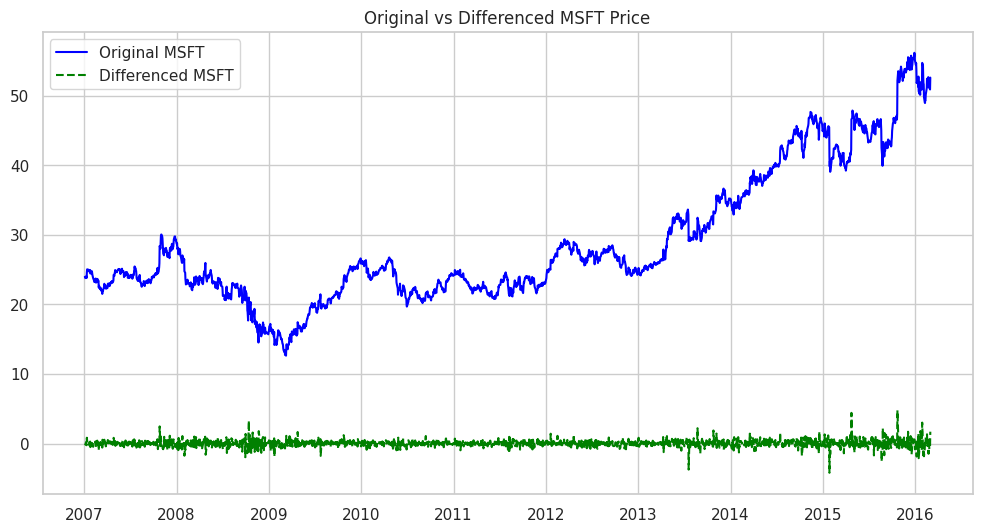

In [16]:
df['MSFT_diff'] = df['MSFT'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['MSFT'], label='Original MSFT', color='blue')
plt.plot(df['MSFT_diff'], label='Differenced MSFT', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced MSFT Price')
plt.show()

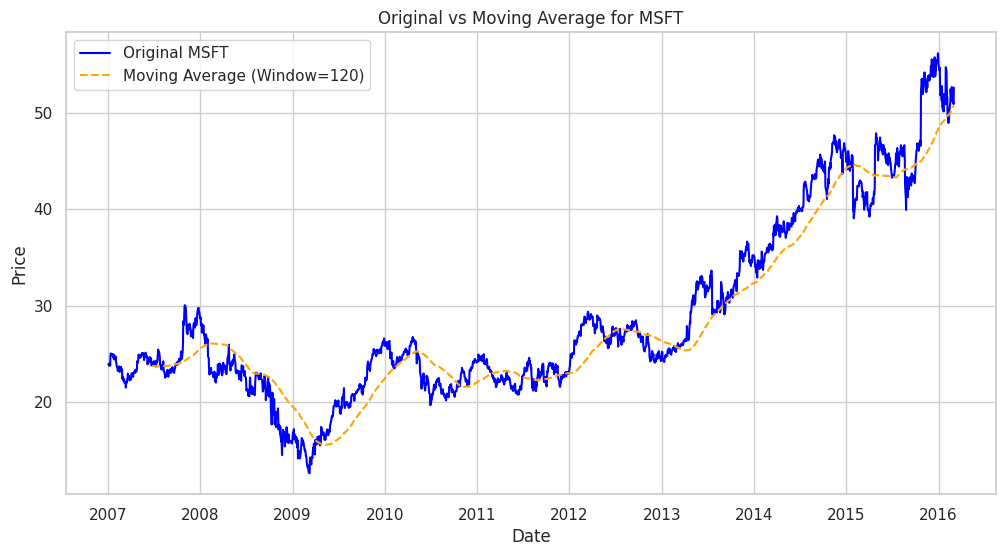

In [18]:
window_size = 120
df['MSFT_smoothed'] = df['MSFT'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['MSFT'], label='Original MSFT', color='blue')
plt.plot(df['MSFT_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Original vs Moving Average for MSFT')
plt.legend()
plt.show()

In [20]:
df_combined = pd.concat([df['MSFT'], df['MSFT_diff']], axis=1)

print(df_combined.head())

                 MSFT  MSFT_diff
Date                            
2007-01-03  23.950705        NaN
2007-01-04  23.910599  -0.040106
2007-01-05  23.774242  -0.136357
2007-01-08  24.006852   0.232610
2007-01-09  24.030914   0.024062


In [22]:
df.dropna(subset=['MSFT_diff'], inplace=True)
df['MSFT_diff'].head()

,MSFT_diff
Date,
2007-01-04,-0.040106
2007-01-05,-0.136357
2007-01-08,0.232610
2007-01-09,0.024062
2007-01-10,-0.240630


In [24]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['MSFT_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -19.574538803141724
p-value: 0.0
Critical Values: {'1%': np.float64(-3.43320007524933), '5%': np.float64(-2.8627990992000947), '10%': np.float64(-2.567440275533058)}
